In [78]:
import numpy as np
import pandas as pd
import seaborn as sns

In [100]:
# 1
df = pd.read_csv("final-employee-ds.csv")
arr = np.array(df["TrainingHours"])
res = arr.astype(float)
res.dtype

dtype('float64')

In [101]:
res.mean()

np.float64(24.19)

In [102]:
res.std()

np.float64(13.842467265628624)

In [32]:
# 2
df.groupby("Department")["Salary"].median()

Department
Finance        91991.0
HR             84078.0
IT            104272.5
Management    106801.0
Marketing     110766.5
Name: Salary, dtype: float64

In [72]:
df["Salary"] = df["Salary"].fillna(df.groupby("Department", dropna=False)["Salary"].median())

In [74]:
res = df[(df["ExperienceYears"] > 12) & (df["ProjectCount"] > 5)]
res = res["Salary"].sum()
res

np.float64(1985775.5)

In [65]:
# 3
res = df[
    ((df["Department"] == "IT") | (df["Department"] == "Finance")) &
    (df["Age"].between(30,45)) &
    (df["PerformanceScore"] > 88)
]

res = res.sort_values(by="Salary", ascending=False)
res = res[["Name", "Department", "Salary", "PerformanceScore"]]
res

,Name,Department,Salary,PerformanceScore
94,Employee_95,IT,140386.0,94
88,Employee_89,Finance,126027.0,92
4,Employee_5,Finance,85543.0,97
32,Employee_33,IT,83919.0,98
55,Employee_56,Finance,49540.0,94


In [71]:
# 4
df["SalaryPerHour"] = df["Salary"]/(df["WorkHoursPerWeek"]*4)
res = df.sort_values(by="SalaryPerHour", ascending=False)
res = res[["Name","SalaryPerHour"]].head(5)
res

,Name,SalaryPerHour
46,Employee_47,981.278571
27,Employee_28,971.292857
31,Employee_32,967.392857
79,Employee_80,945.335526
80,Employee_81,937.858974


<Axes: xlabel='Department', ylabel='count'>

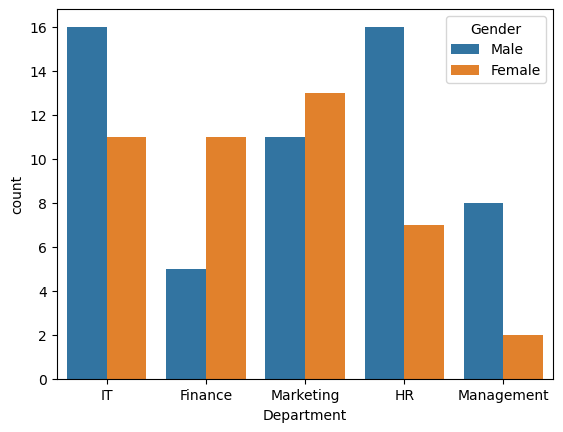

In [90]:
# 5
sns.countplot(data=df, x = "Department", hue = "Gender")